# Cat Health Agentic RAG with LangChain and LangGraph

In Session 1, retrieval happened before every answer:

```text
question -> retrieve -> generate
```

In this notebook, retrieval becomes a **tool**. The agent can call that tool when it decides the user's question needs cat health guideline context.

That is the core idea of agentic RAG for this session:

```text
question -> agent decides whether to retrieve -> optional retrieval tool call -> answer
```

We will show that loop two ways:

1. **High-level LangChain path**: use `create_agent` with middleware.
2. **Explicit LangGraph path**: build the same loop with `StateGraph`, `ToolNode`, and `tools_condition`.

Both versions use the same retriever tool. The point is to see that agentic RAG is about giving the agent retrieval as an action, not forcing retrieval as a pre-step.

## Learning Outcomes

By the end of this notebook, you will be able to:

- Explain how agentic RAG differs from a fixed two-step RAG pipeline.
- Build and inspect a retrieval tool over a Qdrant vector store.
- Use LangChain middleware to observe and constrain an agent loop.
- Compare the convenience of `create_agent` with the control of an explicit LangGraph graph.
- Design focused routing and middleware experiments for an agentic RAG system.

## Table of Contents

- **Breakout Room #1: High-Level Agentic RAG with LangChain**
  - Task 1: Environment Setup
  - Task 2: Load and Index the Cat Health Corpus
  - Task 3: Create a Retriever Tool
  - Task 4: Build an Agent with `create_agent` and Middleware
  - Task 5: Visualize and Stream the `create_agent` Agent
  - 🏗️ Activity #1: Add a Retriever Tool-Call Budget
- **Breakout Room #2: Explicit Agent Loop with LangGraph**
  - Task 6: Build the Same Agent Loop with LangGraph
  - 🏗️ Activity #2: Add Deterministic Scope Routing
  - 🚧 Advanced Build: Add Explicit Retrieval Quality Control

---
# Breakout Room #1
## High-Level Agentic RAG with LangChain

In this breakout room, you will build the shared retrieval tool, give it to `create_agent`, and use middleware and streaming to inspect and constrain the agent loop.

## Task 1: Environment Setup

From the `02_Agentic_RAG_LangGraph_LangChain` folder, install dependencies with uv:

```bash
uv sync
```

Then open this notebook in Cursor or VS Code and select the Python/Jupyter environment created by uv.

### Imports

LangChain gives us document loading, splitting, embeddings, Qdrant integration, tools, models, and the high-level agent loop.

In [95]:
from pathlib import Path
from getpass import getpass
import os

from IPython.display import Image, display

from langchain.agents import create_agent
from langchain.agents.middleware import ModelCallLimitMiddleware, ToolCallLimitMiddleware, before_model
from langchain.tools import tool
from langchain_community.document_loaders import TextLoader
from langchain_core.messages import SystemMessage, ToolMessage
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

### API Keys and Models

The chat model and embedding model both use OpenAI. If `OPENAI_API_KEY` is not already set in your environment, this cell will ask for it securely.

LangSmith tracing is optional. If you set `LANGSMITH_TRACING=true` and `LANGSMITH_API_KEY`, LangChain/LangGraph calls will be traced automatically.

In [99]:
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("OpenAI API Key: ")

os.environ["LANGSMITH_API_KEY"] = getpass("LangSmith API Key: ")

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://eu.api.smith.langchain.com"
os.environ.setdefault("LANGSMITH_PROJECT", "aim-session-3-agentic-rag")

chat_model_name = os.environ.get("AIM_CHAT_MODEL", "gpt-5.4-mini")
embedding_model_name = os.environ.get("AIM_EMBEDDING_MODEL", "text-embedding-3-small")

llm = ChatOpenAI(model=chat_model_name)
embeddings = OpenAIEmbeddings(model=embedding_model_name)

print(f"Chat model: {chat_model_name}")
print(f"Embedding model: {embedding_model_name}")
print(f"LangSmith tracing: {os.environ.get('LANGSMITH_TRACING')}")
print(f"LangSmith endpoint: {os.environ.get('LANGSMITH_ENDPOINT')}")

Chat model: gpt-5.4-mini
Embedding model: text-embedding-3-small
LangSmith tracing: true
LangSmith endpoint: https://eu.api.smith.langchain.com


## Task 2: Load and Index the Cat Health Corpus

We will use a small course-owned Markdown corpus instead of a PDF. This keeps the session focused on the agentic RAG pattern instead of PDF parsing.

**Further Reading:**
- [LangChain Retrieval](https://docs.langchain.com/oss/python/langchain/retrieval)
- [Qdrant LangChain Integration](https://qdrant.tech/documentation/frameworks/langchain/)

In [100]:
corpus_path = Path("data/cat_health_guidelines.md")

if not corpus_path.exists():
    raise FileNotFoundError(
        f"Expected the cat health corpus at: {corpus_path.resolve()}\n"
        "Run this notebook from the 02_Agentic_RAG_LangGraph_LangChain folder."
    )

loader = TextLoader(str(corpus_path), encoding="utf-8")
documents = loader.load()

for document in documents:
    document.metadata["source"] = corpus_path.name
    document.metadata["document_type"] = "cat_health_guidelines"

print(f"Loaded {len(documents)} document(s).")
print(documents[0].page_content[:800])
print("\nMetadata:", documents[0].metadata)

Loaded 1 document(s).
# Cat Health Guidelines

This short teaching corpus is for AI Makerspace retrieval exercises. It is not veterinary advice. Students should use it to practice grounding answers in retrieved context and should recommend contacting a veterinarian for medical decisions.

## Preventive Care

Healthy adult cats should have a wellness exam at least once per year. Kittens, senior cats, cats with chronic disease, and cats taking long-term medication may need more frequent visits. A wellness visit may include a weight check, dental exam, vaccine review, parasite prevention review, and discussion of behavior, appetite, hydration, litter box habits, and activity level.

Preventive care is easier when owners track small changes over time. Useful observations include body weight, appetite, drinking, uri

Metadata: {'source': 'cat_health_guidelines.md', 'document_type': 'cat_health_guidelines'}


### Split the Corpus

Chunks should be large enough to keep a useful idea together, but small enough that retrieval returns focused context.

In [101]:
chunk_size = 900
chunk_overlap = 120

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap,
    add_start_index=True,
    separators=["\n## ", "\n### ", "\n\n", "\n", ". ", " "],
)

splits = text_splitter.split_documents(documents)

for index, split in enumerate(splits):
    split.metadata["chunk_id"] = index

print(f"Created {len(splits)} chunks.")
print(splits[0].page_content[:800])
print("\nMetadata:", splits[0].metadata)

Created 10 chunks.
# Cat Health Guidelines

This short teaching corpus is for AI Makerspace retrieval exercises. It is not veterinary advice. Students should use it to practice grounding answers in retrieved context and should recommend contacting a veterinarian for medical decisions.

Metadata: {'source': 'cat_health_guidelines.md', 'document_type': 'cat_health_guidelines', 'start_index': 0, 'chunk_id': 0}


### Build the Qdrant Vector Store

For the course notebook, Qdrant runs in memory. There is no Docker service or cloud account required, and the collection disappears when the notebook kernel stops.

In [102]:
collection_name = "cat_health_agentic_rag"

vector_store = QdrantVectorStore.from_documents(
    documents=splits,
    embedding=embeddings,
    location=":memory:",
    collection_name=collection_name,
)

retrieval_k = 4
print(f"Built in-memory Qdrant collection: {collection_name}")

Built in-memory Qdrant collection: cat_health_agentic_rag


## Task 3: Create a Retriever Tool

This is the important shift from Session 1.

The retriever is no longer a required pre-step. It is now a tool the agent can call when it wants context from the cat health guideline corpus.

The tool name, docstring, inputs, and output format form a contract with the model. Clear contracts make good tool-selection and grounded-answer behavior more likely.

**Further Reading:**
- [LangChain Tools](https://docs.langchain.com/oss/python/langchain/tools)
- [ReAct: Synergizing Reasoning and Acting in Language Models](https://arxiv.org/abs/2210.03629)

In [103]:
def _format_retrieved_docs(scored_docs: list[tuple]) -> str:
    formatted_chunks = []
    for index, (doc, score) in enumerate(scored_docs, start=1):
        source = doc.metadata.get("source", "unknown")
        chunk_id = doc.metadata.get("chunk_id", "unknown")
        start_index = doc.metadata.get("start_index", "unknown")
        score_text = f"{score:.3f}" if isinstance(score, (float, int)) else str(score)
        formatted_chunks.append(
            f"[Source {index}: {source}, chunk_id={chunk_id}, start_index={start_index}, score={score_text}]\n"
            f"{doc.page_content.strip()}"
        )
    return "\n\n".join(formatted_chunks)


@tool
def retrieve_cat_health_guidelines(query: str) -> str:
    """Search the cat health guideline corpus for relevant context about cat preventive care, nutrition, hydration, vaccines, parasites, dental health, urinary warning signs, emergencies, senior cats, stress, behavior, and safe home monitoring."""
    results = vector_store.similarity_search_with_score(query, k=retrieval_k)
    if not results:
        return "No relevant cat health guideline context found."
    return _format_retrieved_docs(results)


retriever_tool = retrieve_cat_health_guidelines

Try the tool directly once. This is just to understand what the agent will see when it calls the tool.

In [104]:
print(
    retriever_tool.invoke(
        {"query": "What urinary signs suggest a cat needs urgent veterinary care?"}
    )[:2500]
)

[Source 1: cat_health_guidelines.md, chunk_id=5, start_index=3071, score=0.673]
## Symptoms That Need Veterinary Attention

Veterinary attention is recommended when a cat has trouble breathing, collapse, seizures, severe weakness, suspected poisoning, trauma, uncontrolled bleeding, repeated vomiting, repeated diarrhea, inability to urinate, straining to urinate, pale gums, severe pain, or a swollen painful abdomen.

Non-emergency changes can still matter. Schedule a veterinary visit for persistent appetite changes, weight loss, increased thirst, increased urination, new hiding, aggression, overgrooming, hair loss, bad breath, drooling, limping, coughing, sneezing that does not improve, or behavior that is unusual for the cat.

[Source 2: cat_health_guidelines.md, chunk_id=4, start_index=2463, score=0.666]
## Litter Box And Urinary Warning Signs

Changes in litter box behavior can signal stress, pain, urinary disease, constipation, diarrhea, or other illness. Owners should pay attention

#### ❓ Question #1

What changes when retrieval becomes a tool instead of a mandatory first step?

##### Answer:

When retrieval becomes a tool it's only executed when model deemed it to be necessary. Tool description is very important for LLM to understand what actually the tool does. Using tools improves efficiency because unrelated or simple questions skip retrieval entirely. This in result will save both latency and cost. The agent aslo can create its own search query rather than passing the raw user input directly to the retriever. It can even call the retrieval tool multiple times in a single run with different queries to gather broader context. When user asks questions not covered by the corpus LLM can send aan immediate response without wasting a retrieval call on searching for content that is not present.

## Task 4: Way 1 - Build an Agent with `create_agent` and Middleware

`create_agent` builds the agent loop for us:

1. The model reads the user question and available tools.
2. The model either answers directly or asks to call a tool.
3. If it asks for a tool, LangChain executes the tool.
4. The tool result is added back to the message history.
5. The model continues until it produces a final answer.

This is the fastest way to build agentic RAG: give the agent a retriever tool and let the agent decide when to call it.

Middleware hooks into the loop without requiring us to rebuild the graph. Below, custom `before_model` middleware logs each model step, while built-in middleware limits the number of model calls in one run.

**Further Reading:**
- [LangChain Agents](https://docs.langchain.com/oss/python/langchain/agents)
- [LangChain Middleware](https://docs.langchain.com/oss/python/langchain/middleware)

In [105]:
AGENT_SYSTEM_PROMPT = """You are a cat health guideline assistant in an agentic RAG lesson.

You have one retrieval tool: retrieve_cat_health_guidelines.

Use the retrieval tool when the user asks about cat health, cat symptoms, preventive care, nutrition, vaccines, parasites, dental health, urinary signs, senior cats, stress, behavior, or home monitoring.

When you use retrieved context:
- Answer only from that retrieved context.
- Include a short Sources line using the source labels returned by the tool.
- Remind the user to contact a veterinarian for medical decisions, urgent symptoms, or worsening symptoms.

If the user asks something unrelated to cat health, do not call the tool. Briefly say this notebook is scoped to the cat health guideline corpus.
If the retrieved context does not contain enough information, say you do not have enough information in the cat health guidelines to answer.
"""


@before_model
def log_before_model(state, runtime):
    """Log a compact view of each model step in the agent loop."""
    print(f"[middleware] Calling the model with {len(state['messages'])} message(s).")


agent_middleware = [
    log_before_model,
    ModelCallLimitMiddleware(run_limit=4, exit_behavior="end"),
]


agent = create_agent(
    model=llm,
    tools=[retriever_tool],
    system_prompt=AGENT_SYSTEM_PROMPT,
    middleware=agent_middleware,
)

print(type(agent))

<class 'langgraph.graph.state.CompiledStateGraph'>


#### ❓ Question #2

What does middleware let us change or observe without rebuilding the agent loop? Why is a model-call limit useful?

##### Answer:
Middleware is useful to control what is happening in the agent loop. Using middle ware we can track agent behaviour e.g with logging, we can add retries, fallbacks as well as applying limits or guardrails. In langchain we pass middleware in create_agent function. 

A model-call limit prevents the agent from looping indefinitely which could cause increased cost.  Without the limit LLM could decide to call the tool on and on and each iteration would add cost and additional latency. If the agent hits model-call limit and has not retrieved the answer it will be forced to stop. 

## Task 5: Visualize and Stream the `create_agent` Agent

`create_agent` returns a compiled LangGraph graph. We can visualize that graph and stream updates to inspect when the retriever tool was called.

The exact generated graph includes middleware nodes, but its core loop is:

```text
START -> before-model middleware -> model -> after-model middleware -> END
                                                |
                                                | tool call
                                                v
                                              tools
                                                |
                                                +----> loop back to before-model middleware
```

**Further Reading:**
- [LangGraph Streaming](https://docs.langchain.com/oss/python/langgraph/streaming)
- [LangSmith Observability](https://docs.langchain.com/langsmith/observability)

### Visualize the `create_agent` Graph

Run the next cell to render the exact compiled graph, including middleware nodes. If Mermaid PNG rendering is unavailable in your environment, the fallback prints the Mermaid source.

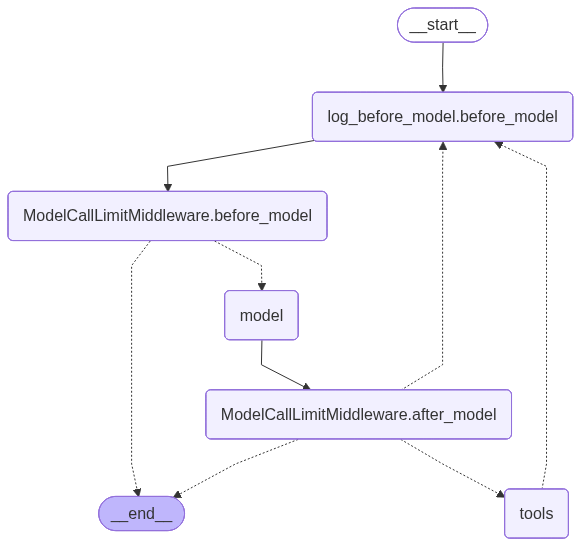

In [106]:
try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("Could not render Mermaid PNG. Mermaid source follows:\n")
    print(agent.get_graph().draw_mermaid())
    print(f"\nRender error: {exc}")

### Stream Agent Runs

Streaming updates lets us inspect the path the agent took. Look for tool messages to see when retrieval happened.

In [107]:
from langgraph.graph.state import CompiledStateGraph
def print_agent_stream(question: str, agent: CompiledStateGraph):
    """Run the agent and print each graph update."""
    inputs = {"messages": [{"role": "user", "content": question}]}

    for chunk in agent.stream(inputs, stream_mode="updates"):
        for node_name, update in chunk.items():
            print(f"\n--- Update from node: {node_name} ---")
            if update is None:
                print("No state update returned.")
                continue

            messages = update.get("messages", [])
            if not messages:
                print(update)
                continue

            latest_message = messages[-1]
            if isinstance(latest_message, ToolMessage):
                print(f"Tool result preview:\n{latest_message.content[:1200]}")
            elif hasattr(latest_message, "pretty_print"):
                latest_message.pretty_print()
            else:
                print(latest_message)

### Example 1: Cat Health Question

This should call the retrieval tool before answering.

In [108]:
print_agent_stream("What urinary signs suggest my cat needs urgent veterinary care?", agent)

[middleware] Calling the model with 1 message(s).

--- Update from node: log_before_model.before_model ---
No state update returned.

--- Update from node: ModelCallLimitMiddleware.before_model ---
No state update returned.

--- Update from node: model ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_wvtLzU139ool4Z1dayoGSFJ2)
 Call ID: call_wvtLzU139ool4Z1dayoGSFJ2
  Args:
    query: urinary signs urgent veterinary care cat warning signs emergency inability to urinate blood in urine straining frequent trips litter box pain

--- Update from node: ModelCallLimitMiddleware.after_model ---
{'thread_model_call_count': 1, 'run_model_call_count': 1}

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=4, start_index=2463, score=0.771]
## Litter Box And Urinary Warning Signs

Changes in litter box behavior can signal stress, pain, urinary disease, constipation, 

### Example 2: Another Cat Health Question

This should also retrieve, but with a different search query.

In [109]:
print_agent_stream("What preventive care should an adult cat get each year?", agent)

[middleware] Calling the model with 1 message(s).

--- Update from node: log_before_model.before_model ---
No state update returned.

--- Update from node: ModelCallLimitMiddleware.before_model ---
No state update returned.

--- Update from node: model ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_s52nQXF3tZpy4nwb2ndsFLlK)
 Call ID: call_s52nQXF3tZpy4nwb2ndsFLlK
  Args:
    query: preventive care adult cat each year annual checkup vaccines parasite control dental care home monitoring

--- Update from node: ModelCallLimitMiddleware.after_model ---
{'thread_model_call_count': 1, 'run_model_call_count': 1}

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=1, start_index=268, score=0.763]
## Preventive Care

Healthy adult cats should have a wellness exam at least once per year. Kittens, senior cats, cats with chronic disease, and cats taking long-term 

### Example 3: Unrelated Question

This should not call the retrieval tool.

In [110]:
print_agent_stream("Who won the 2022 FIFA World Cup?", agent)

[middleware] Calling the model with 1 message(s).

--- Update from node: log_before_model.before_model ---
No state update returned.

--- Update from node: ModelCallLimitMiddleware.before_model ---
No state update returned.

--- Update from node: model ---
================================== Ai Message ==================================

This notebook is scoped to the cat health guideline corpus, so I can’t answer that general knowledge question.

--- Update from node: ModelCallLimitMiddleware.after_model ---
{'thread_model_call_count': 1, 'run_model_call_count': 1}


#### ❓ Question #3

For each example, did the agent call the retrieval tool? Why or why not?

##### Answer:

We can see that in example 1 and 2 the question was related to cat so the LLM used to tool to retrieve information from the RAG.

For example 3 where question was not related to cats LLM decided not to call the tool and responded to user directly that the question is not related to cat health guidelines and that it can't help user with it's query. It demonstrates the conditional edge/routing logic in the agent graph.

## 🏗️ Activity #1: Add a Retriever Tool-Call Budget

Middleware can enforce an operational rule without changing the retriever tool or rebuilding the agent graph. Create a second agent that allows at most **one** call to `retrieve_cat_health_guidelines` per run.

### Requirements

1. Create a `ToolCallLimitMiddleware` instance scoped to `retriever_tool.name` with `run_limit=1` and `exit_behavior="continue"`.
2. Create `budgeted_agent` with the same model, tool, prompt, and existing middleware plus the new retrieval budget.
3. Ask the agent to use separate searches for urinary emergency signs and annual preventive care before summarizing both.
4. Inspect the stream and explain what the middleware allowed or blocked.

**Further Reading:**
- [Built-in Middleware](https://docs.langchain.com/oss/python/langchain/middleware/built-in)

In [111]:
# Activity #1 workspace
retrieval_budget = ToolCallLimitMiddleware(tool_name=retriever_tool.name, run_limit=1, exit_behavior="continue")

budget_agent_middleware = [
    log_before_model,
    retrieval_budget
]

budgeted_agent = create_agent( model=llm,
    tools=[retriever_tool],
    system_prompt=AGENT_SYSTEM_PROMPT,
    middleware=budget_agent_middleware,)


In [112]:
#Attempt 1
print_agent_stream("What urinary signs suggest my cat needs urgent veterinary care and what preventive care should an adult cat get each year?", budgeted_agent)

[middleware] Calling the model with 1 message(s).

--- Update from node: log_before_model.before_model ---
No state update returned.

--- Update from node: model ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_41VtsX5W8WZd3NOUVeeazL2v)
 Call ID: call_41VtsX5W8WZd3NOUVeeazL2v
  Args:
    query: urinary signs urgent veterinary care cat emergency signs urinary signs adult cat preventive care yearly annual preventive care
  retrieve_cat_health_guidelines (call_LZCRnRhvQ4mUHmbsL9vIbrTx)
 Call ID: call_LZCRnRhvQ4mUHmbsL9vIbrTx
  Args:
    query: annual preventive care for adult cat each year vaccines parasite prevention dental exam physical exam weight monitoring home monitoring

--- Update from node: ToolCallLimitMiddleware[retrieve_cat_health_guidelines].after_model ---
Tool result preview:
Tool call limit exceeded. Do not call 'retrieve_cat_health_guidelines' again.

--- Update from node: tools ---
Too

In [114]:
# Try to prompt agent to do two searches so we can see if the limit is enforced
print_agent_stream("Do one search for urinary emergency signs and then a separate search for annual preventive care. Summarize both.", budgeted_agent)

[middleware] Calling the model with 1 message(s).

--- Update from node: log_before_model.before_model ---
No state update returned.

--- Update from node: model ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_8L4kXCcXhPVe6WK4K2ydZpGR)
 Call ID: call_8L4kXCcXhPVe6WK4K2ydZpGR
  Args:
    query: urinary emergency signs in cats
  retrieve_cat_health_guidelines (call_hTVkKBZYvKvQ38hkpUBAD7P6)
 Call ID: call_hTVkKBZYvKvQ38hkpUBAD7P6
  Args:
    query: annual preventive care for cats

--- Update from node: ToolCallLimitMiddleware[retrieve_cat_health_guidelines].after_model ---
Tool result preview:
Tool call limit exceeded. Do not call 'retrieve_cat_health_guidelines' again.

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=4, start_index=2463, score=0.655]
## Litter Box And Urinary Warning Signs

Changes in litter box behavior can signal stress, pain, urin

Now we can see in 2nd example the agent attempted __2 tool__ calls in __one step__, but the middleware blocked the second one:

- Allowed: "urinary emergency signs in cats" — returned results
- Blocked: "annual preventive care for cats" — got "Tool call limit exceeded. Do not call 'retrieve_cat_health_guidelines' again."

That's why the agent answered the urinary part with retrieved context but said "I do not have enough information" for preventive care (those chunks were not retrieved due to middleware blocking 2nd tool call).

### 📝 Activity #1 Notes

- Which retrieval calls did the agent attempt?
- Which call did the middleware allow or block?
- What quality or safety trade-off does this budget introduce?

##### Answer:

1) 
When i combined two questions in one agent was smart enough to do only one tool call combining the question and got the answer for both questions. 

The middleware didn't kick in.  In the second try i explicitly asked the LLM to do one search for urinary emergency signs and then a separate search for annual preventive care and at the end summarize me both. The agent attempted 2 tool calls in one step, but the middleware blocked the second one due to middleware 1-call limit. That's exactly what we want to observe. The budget enforced the 1-call limit, and the quality trade-off is visible: the agent couldn't fully answer (although the information could have been retrieved) because it was denied a second tool call.

2) In the second try the middleware blocked second tool call.

3) Safety and budget gains are clear. The middleware protects us from the agent getting into an infinite loop and increasing cost and latency. The drawback of the middleware in the example above was the fact that user did not receive answer on his question due to the fact that second tool call was blocked. The information was present in the knowledge base so the user received an incomplete answer despite the information being available.

## Breakout Room #1 Summary

In BOR1, you:

- Turned retrieval into a source-labeled tool the model can choose to call.
- Built a high-level agent loop with `create_agent`.
- Used middleware to observe the loop and constrain model or tool calls.
- Used streaming to inspect retrieval decisions instead of judging only the final answer.

---
# Breakout Room #2
## Explicit Agent Loop with LangGraph

In this breakout room, you will rebuild the same model-tools loop explicitly, then add routing behavior that would require graph-level control.

## Task 6: Way 2 - Build the Same Agent Loop with LangGraph

Now we will build the minimal agent loop ourselves.

This is the same idea as `create_agent`, but expressed directly as a graph:

```text
START -> agent model -------------------------------> END
              |
              | tool call
              v
            tools
              |
              +---------------------> agent model
```

There is still no mandatory pre-retrieval step. Retrieval only happens if the model emits a tool call. Unlike middleware, graph nodes and conditional edges let us change the control flow itself.

**Further Reading:**
- [LangGraph Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api)
- [LangGraph Workflows and Agents](https://docs.langchain.com/oss/python/langgraph/workflows-agents)

In [115]:
llm_with_tools = llm.bind_tools([retriever_tool])


def call_model(state: MessagesState):
    """Call the model with tools bound so it can choose whether to retrieve."""
    response = llm_with_tools.invoke(
        [SystemMessage(content=AGENT_SYSTEM_PROMPT)] + state["messages"]
    )
    return {"messages": [response]}


langgraph_builder = StateGraph(MessagesState)
langgraph_builder.add_node("agent", call_model)
langgraph_builder.add_node("tools", ToolNode([retriever_tool], handle_tool_errors=True))

langgraph_builder.add_edge(START, "agent")
langgraph_builder.add_conditional_edges("agent", tools_condition)
langgraph_builder.add_edge("tools", "agent")

langgraph_agent = langgraph_builder.compile()
print("Compiled the explicit LangGraph agent loop.")


Compiled the explicit LangGraph agent loop.


### Visualize the Explicit LangGraph Agent

This graph should look like the core agent loop: model node, tools node, and a conditional route between them.

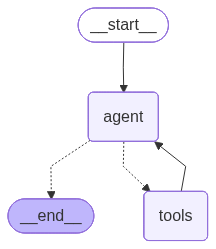

In [116]:
try:
    display(Image(langgraph_agent.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("Could not render Mermaid PNG. Mermaid source follows:\n")
    print(langgraph_agent.get_graph().draw_mermaid())
    print(f"\nRender error: {exc}")

### Stream the Explicit LangGraph Agent

This helper is intentionally similar to `print_agent_stream`. The difference is that we are streaming from the graph we built ourselves.

In [117]:
def print_langgraph_stream(question: str):
    """Run the explicit LangGraph agent and print each graph update."""
    inputs = {"messages": [{"role": "user", "content": question}]}

    for chunk in langgraph_agent.stream(inputs, stream_mode="updates"):
        for node_name, update in chunk.items():
            print(f"\n--- Update from node: {node_name} ---")
            messages = update.get("messages", [])
            if not messages:
                print(update)
                continue

            latest_message = messages[-1]
            if isinstance(latest_message, ToolMessage):
                print(f"Tool result preview:\n{latest_message.content[:1200]}")
            elif hasattr(latest_message, "pretty_print"):
                latest_message.pretty_print()
            else:
                print(latest_message)

### Compare the Same Questions

Run the same style of questions through the explicit LangGraph agent. The exact wording may differ, but the retrieval decision should follow the same pattern.

In [118]:
print_langgraph_stream("What urinary signs suggest my cat needs urgent veterinary care?")


--- Update from node: agent ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_Kx4sQwEiL4AWQQI4YtuyGdlj)
 Call ID: call_Kx4sQwEiL4AWQQI4YtuyGdlj
  Args:
    query: urinary signs suggest cat needs urgent veterinary care emergency symptoms blood in urine straining unable to urinate frequent trips litter box pain vocalizing

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=4, start_index=2463, score=0.742]
## Litter Box And Urinary Warning Signs

Changes in litter box behavior can signal stress, pain, urinary disease, constipation, diarrhea, or other illness. Owners should pay attention to straining, frequent trips to the litter box, crying in the box, blood in urine, urinating outside the box, producing very little urine, or not producing urine.

A cat that is straining to urinate, repeatedly visiting the litter box, crying, or producing little or no uri

In [ ]:
print_langgraph_stream("Who won the 2022 FIFA World Cup?")


--- Update from node: agent ---
================================== Ai Message ==================================

This notebook is scoped to the cat health guideline corpus, so I can’t answer that question here.


#### ❓ Question #4

What parts did `create_agent` hide that the explicit LangGraph version made visible? When would you choose middleware, and when would you change the graph itself?

##### Answer:

Using `create_agent` we passed in the model, tools, prompt and middleware and we got working agent. The graph nodes were hidden from our view. Agent node and tools node were created but we didn't have to define them. That was done automatically

Middleware should be chosen when we want to add extra behaviour without changing the flow of the system. That could include logging, metrics, tracking, rate limits (as we applied above), adding guardrails or retries. 

You would change to a graph when you need to change the control flow e.g., adding a human-in-the-loop approval step, conditional branching based on response quality etc.

## 🏗️ Activity #2: Add Deterministic Scope Routing

The base LangGraph sends every question to the model and relies on the model to reject unrelated requests. Add a small deterministic route before the agent so clearly unrelated questions can bypass the model-tools loop.

### Requirements

1. Add an `out_of_scope` node that returns a brief scope message.
2. Add a routing function that sends likely cat-health questions to `agent` and clearly unrelated questions to `out_of_scope`.
3. Build and compile a new graph with the route immediately after `START`.
4. Test at least one cat-health question, one unrelated question, and one ambiguous question.
5. Explain where the deterministic route helps and where it is brittle.

**Further Reading:**
- [LangGraph Conditional Edges](https://docs.langchain.com/oss/python/langgraph/graph-api#conditional-edges)

In [121]:
# Activity #2 workspace
# FLOW: START → route_question → agent → tools ↔ agent → END → out_of_scope → END

CAT_HEALTH_KEYWORDS = {
    "cat", "cats", "kitten", "kittens", "feline", "felines", "kitteh",
    # health topics from the corpus
    "vaccine", "vaccines", "vaccination", "vaccinate",
    "parasite", "parasites", "flea", "fleas", "tick", "ticks", "worm", "worms",
    "dental", "teeth", "gums", "breath",
    "urinary", "urine", "urinate", "litter", "bladder",
    "vomit", "vomiting", "diarrhea", "constipation",
    "nutrition", "diet", "hydration", "food", "feeding",
    "senior", "elderly", "aging",
    "neuter", "spay",
    "vet", "veterinary", "veterinarian",
    # symptoms
    "limping", "coughing", "sneezing", "drooling", "grooming",
    "overgrooming", "hiding", "aggression", "seizure", "seizures",
    "weight loss", "appetite",
}

def route_question(state: MessagesState) -> str:
    """Route based on keyword presence in the user's last message."""
    last_message = state["messages"][-1].content.lower()
    if any(keyword in last_message for keyword in CAT_HEALTH_KEYWORDS):
        print(f"[router] keyword match found. Routing to agent")
        return "agent"
    print(f"[router] no keyword match. Routing to out_of_scope")
    return "out_of_scope"

def out_of_scope(state: MessagesState):
    """Return a canned response for non-cat-health questions."""
    return {
        "messages": [{"role": "assistant", "content": "This system only answers questions about cat health guidelines."}]
    }

#build graph
guarded_builder = StateGraph(MessagesState)
guarded_builder.add_node("out_of_scope", out_of_scope)
guarded_builder.add_node("agent", call_model)
guarded_builder.add_node("tools", ToolNode([retriever_tool], handle_tool_errors=True))

guarded_builder.add_conditional_edges(START, route_question)
guarded_builder.add_conditional_edges("agent", tools_condition)
guarded_builder.add_edge("tools", "agent")
guarded_builder.add_edge("out_of_scope", END)

routed_agent = guarded_builder.compile()
print("Compiled the routed LangGraph agent.")



Compiled the routed LangGraph agent.


In [122]:
print_agent_stream("What vaccines does my kitten need?", routed_agent)

[router] keyword match found. Routing to agent

--- Update from node: agent ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_wfE7mgI27lhk3nOVHJW0SF6W)
 Call ID: call_wfE7mgI27lhk3nOVHJW0SF6W
  Args:
    query: kitten vaccines needed core vaccines schedule FVRCP rabies leukemia when to vaccinate kitten

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=2, start_index=997, score=0.572]
## Vaccines And Parasite Prevention

Core vaccines are commonly recommended for cats because they protect against serious contagious diseases. Vaccine schedules depend on age, prior vaccine history, local disease risk, indoor or outdoor lifestyle, and veterinarian guidance. Cats that go outdoors, live with other animals, board, travel, or have unknown exposure risk may need additional protection.

Parasite prevention should be discussed with a veterinarian. Fleas, ticks, e

In [123]:
print_agent_stream("Who won Roland-Garros yesterday?", routed_agent)

[router] no keyword match. Routing to out_of_scope

--- Update from node: out_of_scope ---
{'role': 'assistant', 'content': 'This system only answers questions about cat health guidelines.'}


In [124]:
print_agent_stream("My pet is not eating and seems lethargic", routed_agent)


[router] no keyword match. Routing to out_of_scope

--- Update from node: out_of_scope ---
{'role': 'assistant', 'content': 'This system only answers questions about cat health guidelines.'}


Short explenation:

Deterministic router saves cost and latency by skipping the LLM entirely for clearly off-topic questions (e.g., "Who won Roland-Garros?"). No tokens are spent, and the response is instant. Keyword matching fails on valid cat-health questions that don't use exact keywords. "My pet is not eating and seems lethargic" is likely about a cat but has no keyword match, so it gets incorrectly rejected. The route also can't handle synonyms, misspellings, or indirect references.

### 📝 Activity #2 Notes

- Which questions bypassed the model-tools loop?
- What happened with the ambiguous question?
- What are the cost, latency, and quality trade-offs of this route?

##### Answer:



- "Who won the World Cup?" - routed to out_of_scope, skipped the LLM entirely
- "My pet is not eating and seems lethargic" → also routed to out_of_scope (incorrectly) as no cat keyword matched (slightly ambigous question), so it got the canned response even though it was likely a cat health question
- "What vaccines does my kitten need?" - keyword was matched so query was answered.

Cost/latency/quality trade-offs:

Cost/latency win — unrelated questions skip the LLM call entirely
Quality risk — keyword matching is brittle; valid questions without exact keywords get rejected
Could improve with embedding similarity or a broader keyword list, but that adds complexity

## 🚧 Advanced Build (Optional): Add Explicit Retrieval Quality Control

The base assignment shows the minimal agentic RAG loop two ways:

1. `create_agent`
2. explicit LangGraph

If you want more control, extend the explicit LangGraph version with retrieval quality control. Good advanced additions include:

- Add a document relevance grader after retrieval.
- Add a query rewrite node when retrieval is weak.
- Add a loop limit so the agent cannot keep retrying forever.
- Add a deterministic guardrail before answering.

Those are useful production patterns, but they are not required for the core idea of agentic RAG.

For this advanced build i will start with a diagram of what i want to build: 

I will improve previous implementation of route_question function and make it more smart. As a first step we will still do keyword matching but if the keyword is not matched we will do check with llm to see if the question can be related to cats e.g user could mention pet so we need to infer if the pet could refer to a cat.


The full flow when grader deams retrieved information __not relevant__

1. Router → keyword match → agent
2. Agent → called retrieval tool
3. Grader → not_relevant
4. Rewrite attempt 1 → rephrased query → retrieved again → still not_relevant
4. Rewrite attempt 2 → rephrased again → retrieved again → still not_relevant
5. Retry limit reached → sent to agent to answer with what it has

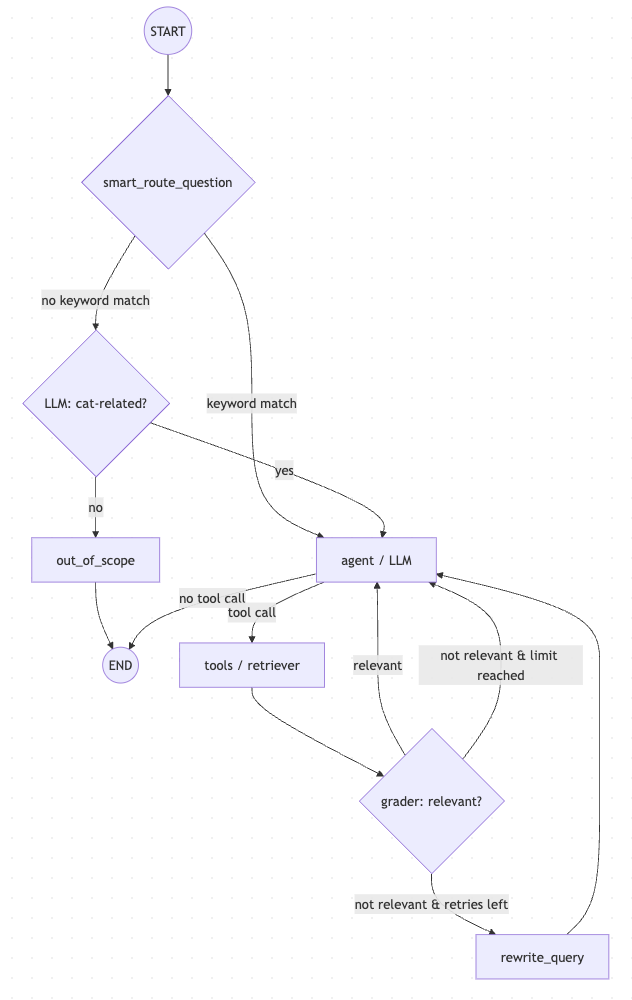
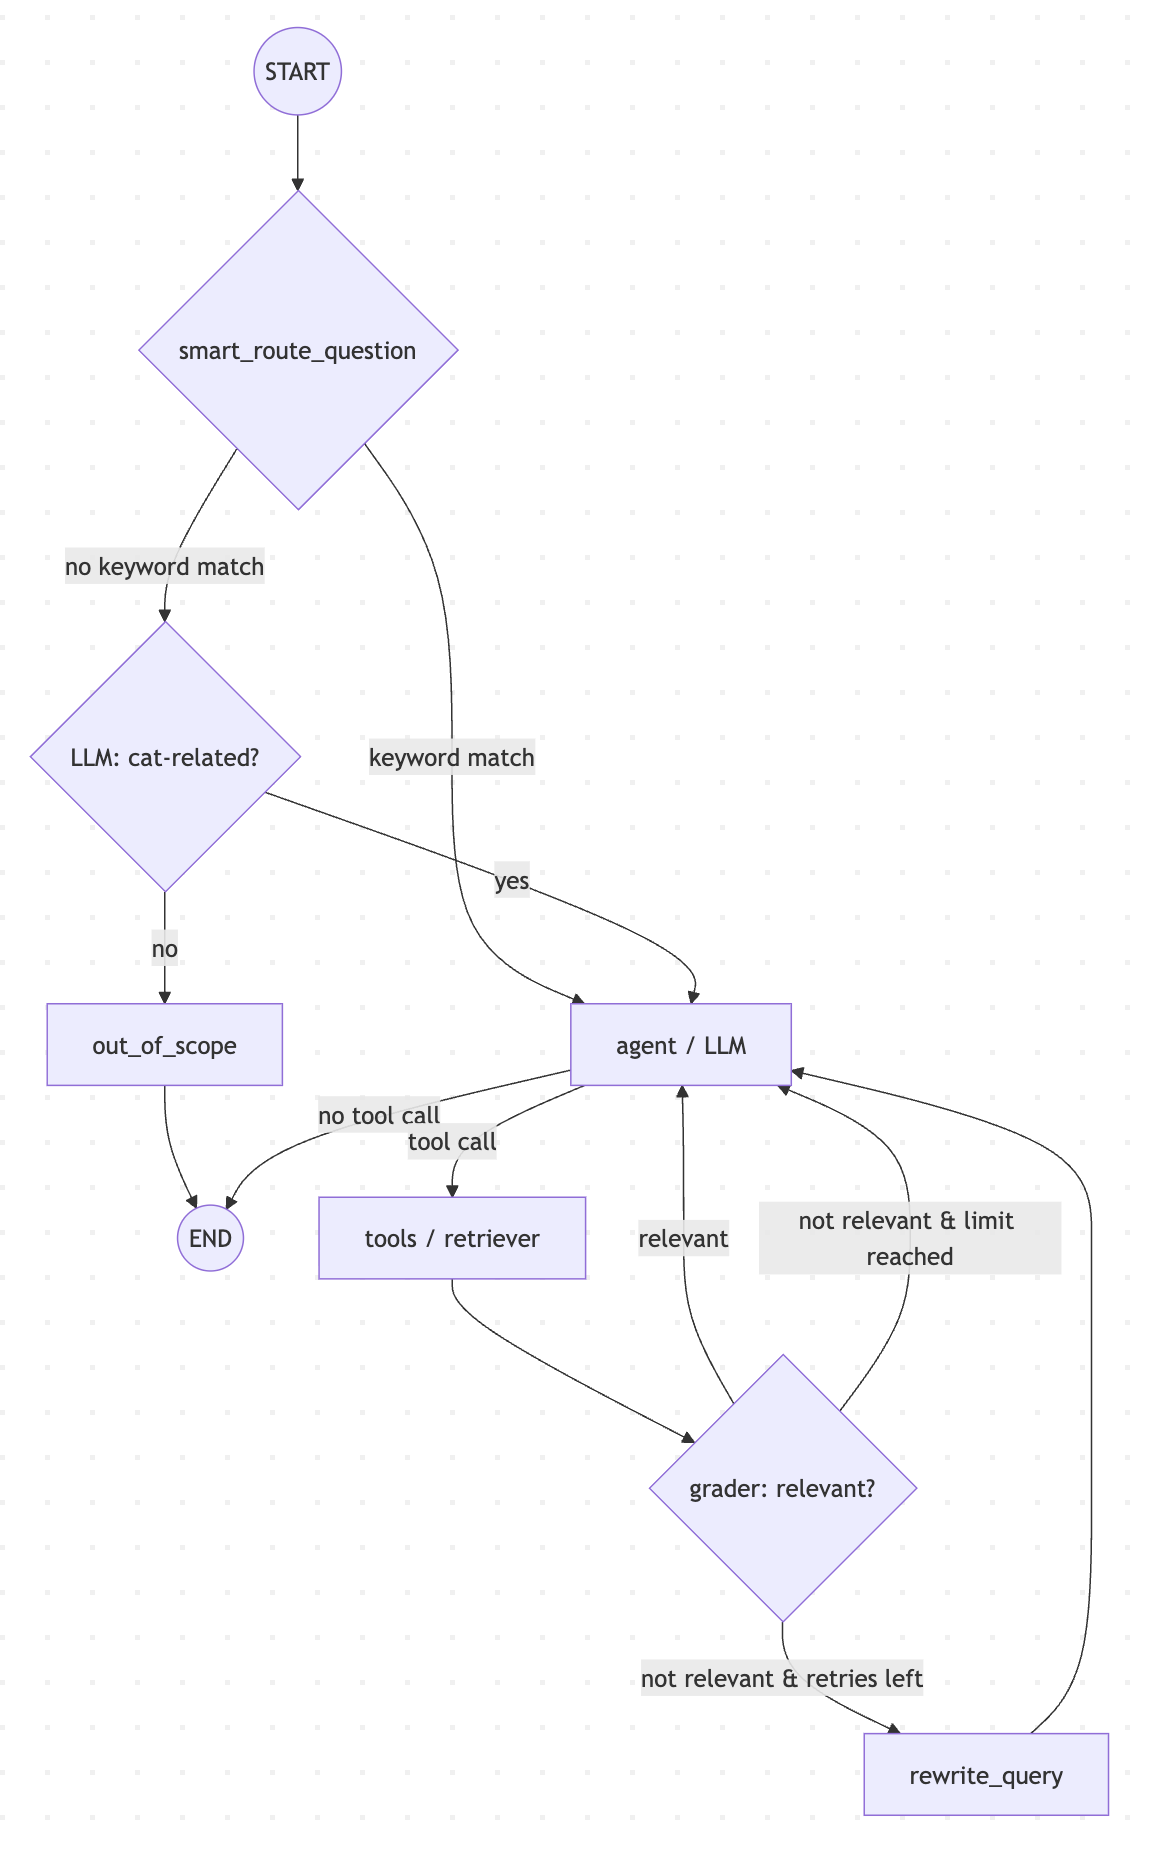

In [ ]:
class AgentState(MessagesState):
    relevance: str        # "relevant" or "not_relevant"
    retry_count: int      # tracks rewrite attempts

def smart_route_question(state: MessagesState) -> str:
    """Two-tier router: keywords first, then LLM fallback."""
    last_message = state["messages"][-1].content.lower()

    if any(keyword in last_message for keyword in CAT_HEALTH_KEYWORDS):
        print("[router] keyword match found → agent")
        return "agent"

    response = llm.invoke(
        f"Is this question related to cat health? Answer only 'yes' or 'no'.\n\nQuestion: {last_message}"
    )
    answer = response.content.strip().lower()
    if "yes" in answer:
        print(f"[router] LLM: question is cat-related. Route to agent")
        return "agent"

    print(f"[router] LLM: Question is not cat-related. Route to out_of_scope")
    return "out_of_scope"


In [ ]:
GRADER_PROMPT = """
  You are a strict relevance grader. The retrieved documents must DIRECTLY answer the question to be considered relevant. If the documents only mention related topics but don't contain a specific answer, respond 'not_relevant'.

  Question: {question}

  Documents: {documents}
"""

def grade_documents(state: AgentState):
    """Check if retrieved documents are relevant to the question."""
    user_question = state["messages"][0].content
    tool_result = state["messages"][-1].content

    response = llm.invoke(
        GRADER_PROMPT.format(question=user_question, documents=tool_result[:2000])
    )
    grade = response.content.strip().lower()
    print(f"[grader] {grade}")
    return {"relevance": grade}


In [ ]:
REWRITE_PROMPT = """
  The retrieved documents were not relevant enough to answer this question.
  Rewrite the question to improve retrieval. Return only the rewritten question.

  Original question: {question}
"""

def rewrite_query(state: AgentState):
    """Rewrite the user's question for better retrieval."""
    user_question = state["messages"][0].content
    retry_count = state.get("retry_count", 0)

    response = llm.invoke(REWRITE_PROMPT.format(question=user_question))
    rewritten = response.content.strip()
    print(f"[rewrite]: Attempt {retry_count + 1}: {rewritten}")

    return {
        "messages": [{"role": "user", "content": rewritten}],
        "retry_count": retry_count + 1,
    }


In [ ]:
MAX_RETRIES = 2

def route_after_grading(state: AgentState) -> str:
    """Decide next step based on relevance and retry count."""
    if state["relevance"] == "relevant":
        print("[route] documents relevant → agent")
        return "agent"

    if state.get("retry_count", 0) >= MAX_RETRIES:
        print("[route] retry limit reached → agent (answer with what we have)")
        return "agent"

    print("[route] not relevant, retrying → rewrite_query")
    return "rewrite_query"


In [ ]:
advanced_builder = StateGraph(AgentState)

advanced_builder.add_node("agent", call_model)
advanced_builder.add_node("tools", ToolNode([retriever_tool], handle_tool_errors=True))
advanced_builder.add_node("out_of_scope", out_of_scope)
advanced_builder.add_node("grader", grade_documents)
advanced_builder.add_node("rewrite_query", rewrite_query)

advanced_builder.add_conditional_edges(START, smart_route_question)
advanced_builder.add_conditional_edges("agent", tools_condition)
advanced_builder.add_edge("tools", "grader")
advanced_builder.add_conditional_edges("grader", route_after_grading)
advanced_builder.add_edge("rewrite_query", "agent")
advanced_builder.add_edge("out_of_scope", END)

advanced_agent = advanced_builder.compile()
print("Compiled the advanced LangGraph agent.")


Compiled the advanced LangGraph agent.


In [ ]:
print_agent_stream("Who has won Roland-Garros in 2026?", advanced_agent)

[router] LLM: Question is not cat-related. Route to out_of_scope

--- Update from node: out_of_scope ---
{'role': 'assistant', 'content': 'This system only answers questions about cat health guidelines.'}


In [ ]:
print_agent_stream("What vaccines does my kitten need?", advanced_agent)

[router] keyword match found → agent

--- Update from node: agent ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_lSOyeSN3gyj6XFbZW8vnPQGb)
 Call ID: call_lSOyeSN3gyj6XFbZW8vnPQGb
  Args:
    query: kitten vaccines core vaccines schedule rabies panleukopenia calicivirus herpesvirus feline leukemia recommendations

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=2, start_index=997, score=0.627]
## Vaccines And Parasite Prevention

Core vaccines are commonly recommended for cats because they protect against serious contagious diseases. Vaccine schedules depend on age, prior vaccine history, local disease risk, indoor or outdoor lifestyle, and veterinarian guidance. Cats that go outdoors, live with other animals, board, travel, or have unknown exposure risk may need additional protection.

Parasite prevention should be discussed with a veterinarian. Fl

In [ ]:
print_agent_stream("My pet is not eating and seems lethargic", advanced_agent)


[router] LLM: question is cat-related. Route to agent

--- Update from node: agent ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_fniB5e06S7wTGSYv8nZVoMBs)
 Call ID: call_fniB5e06S7wTGSYv8nZVoMBs
  Args:
    query: cat not eating lethargic urgent symptoms home monitoring when to contact veterinarian

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=5, start_index=3071, score=0.650]
## Symptoms That Need Veterinary Attention

Veterinary attention is recommended when a cat has trouble breathing, collapse, seizures, severe weakness, suspected poisoning, trauma, uncontrolled bleeding, repeated vomiting, repeated diarrhea, inability to urinate, straining to urinate, pale gums, severe pain, or a swollen painful abdomen.

Non-emergency changes can still matter. Schedule a veterinary visit for persistent appetite changes, weight loss, increased thirst, incr

#### Final conclusions for advanced build

In this advanced built i have built an advanced agentic RAG pipeline with four key improvements over the base implementation:
1. **Two-tier smart routing**: keyword matching runs first (free, instant). If no keyword matches, an LLM fallback checks if the question is cat-related. This fixed the brittleness from Activity #2 where "My pet is not eating" was incorrectly routed to out_of_scope (pet could be a cat).

2. **Relevance grading**: after retrieval, the grader checks if the retrieved documents actually answer the question. This catches cases where the vector store returns chunks that are semantically close but don't contain the specific answer.

3. **Query rewriting with retry loop**: when the grader says "not_relevant", the system rephrases the question and retries retrieval. This gives the agent a second (and third) chance to find useful context before returning data to the user.

4. **Retry count limit**: a maximum retry count (in our case MAX_RETRIES=2) prevents infinite rewrite loops. When the limit is reached, the agent answers with whatever context it has and honestly says what it couldn't find.


Key observations:

- The ambiguous "pet not eating" question showed the LLM router correctly inferring cat-relatedness without any cat keyword present.

Trade-offs:

- Cost: each grader call and rewrite adds an LLM invocation. A single run can now make 4+ LLM calls (router, agent, grader, rewrite, agent again).
- Latency: the rewrite loop adds seconds per retry.
- Quality: significantly better than the base version. The system either finds relevant context or honestly admits it doesn't have the information.

---
## Summary

In this session, you:

1. Built a retrieval tool over a Qdrant vector store.
2. Used `create_agent` and middleware for a high-level agentic RAG loop.
3. Streamed agent runs to inspect when retrieval happened.
4. Rebuilt the loop explicitly with LangGraph nodes and conditional edges.
5. Practiced choosing between middleware-level constraints and graph-level routing.

### Key Takeaways

- Agentic RAG makes retrieval an available action instead of a mandatory pre-step.
- Tool contracts and system prompts strongly influence retrieval decisions.
- Middleware is useful for cross-cutting behavior such as logging, limits, retries, and guardrails.
- Explicit graphs are useful when the application needs custom state or control flow.
- Inspecting intermediate events is essential because a plausible final answer can hide a poor agent path.

### Further Reading

- [LangChain Agents](https://docs.langchain.com/oss/python/langchain/agents)
- [LangChain Middleware](https://docs.langchain.com/oss/python/langchain/middleware)
- [LangGraph Overview](https://docs.langchain.com/oss/python/langgraph/overview)
- [LangSmith Observability](https://docs.langchain.com/langsmith/observability)

### Notebook Output Guidance

Keep useful outputs when you submit, especially graph diagrams and representative streamed runs that support your observations. Remove secrets, failed experiments that no longer matter, and excessively noisy output.